# MERIDIAN - Analysis Module 5: Marketing Channel Attribution (Lite)

## Business question
Which marketing channels are actually worth the spend? This notebook computes, per channel and region:

- **CAC (Customer Acquisition Cost)** - ad spend divided by how many *new* customers that channel brought in.
- **ROAS (Return on Ad Spend)** - total revenue attributed to a channel, divided by what was spent on it.

## Attribution model: last-touch
Each order is tagged with a single channel - whichever one gets credit for that specific order. For CAC specifically, only a customer's very *first* order counts as an 'acquisition' - repeat orders from an already-acquired customer don't count as a new acquisition, regardless of which channel drove that later order.

## A significant limitation, upfront
This data is entirely synthetic and only exists for three regions (US, DE, GH) - no real e-commerce dataset publicly tracks ad spend or channel attribution, so Brazil and the UK are absent from this module entirely. Treat every number below as illustrative of the *method*, not as a real business finding - unlike every other module in this project, which analyzes genuine or calibrated-against-genuine data.

## Step 1 - Connect and load the three pieces this needs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import pyodbc

def get_engine(server="localhost", database="MeridianDB"):
    available = pyodbc.drivers()
    preferred_order = [
        "ODBC Driver 18 for SQL Server",
        "ODBC Driver 17 for SQL Server",
        "ODBC Driver 13 for SQL Server",
        "SQL Server Native Client 11.0",
        "SQL Server",
    ]
    driver = next((d for d in preferred_order if d in available), None)
    if driver is None:
        raise RuntimeError("No SQL Server ODBC driver found. Install 'ODBC Driver 17 for SQL Server'.")
    conn_str = f"mssql+pyodbc://@{server}/{database}?driver={driver.replace(' ', '+')}&trusted_connection=yes"
    return create_engine(conn_str)

engine = get_engine()

orders = pd.read_sql("SELECT order_id, customer_id, region, order_date, amount_usd FROM marts.fct_orders", engine)
attribution = pd.read_sql("SELECT order_id, region, channel FROM raw.order_channel_attribution", engine)
spend = pd.read_sql("SELECT date, region, channel, spend_usd FROM raw.channel_spend", engine)

orders['order_date'] = pd.to_datetime(orders['order_date'])
print(f"{len(orders):,} total orders (all regions)")
print(f"{len(attribution):,} orders have channel attribution (synthetic regions only)")
print(f"{len(spend):,} daily spend records")

159,120 total orders (all regions)
6,051 orders have channel attribution (synthetic regions only)
16,440 daily spend records


## Step 2 - Join orders to their attributed channel

An inner join here automatically limits everything downstream to only the orders that have attribution data - i.e. only US/DE/GH, exactly as expected.

In [2]:
attributed_orders = orders.merge(attribution[['order_id', 'channel']], on='order_id', how='inner')
print(f"{len(attributed_orders):,} orders successfully matched to a channel")
attributed_orders['region'].value_counts()

6,051 orders successfully matched to a channel


region
US    2018
DE    2017
GH    2016
Name: count, dtype: int64

## Step 3 - ROAS by channel and region

In [3]:
revenue_by_channel = attributed_orders.groupby(['region', 'channel'])['amount_usd'].sum().rename('revenue_usd')
spend_by_channel = spend.groupby(['region', 'channel'])['spend_usd'].sum()

roas = pd.concat([revenue_by_channel, spend_by_channel], axis=1)
roas['ROAS'] = roas['revenue_usd'] / roas['spend_usd']
roas = roas.round(2).sort_values('ROAS', ascending=False)
roas

,,revenue_usd,spend_usd,ROAS
region,channel,,,
DE,organic,48412.27,18551.71,2.61
US,organic,44855.39,21813.26,2.06
GH,organic,16528.85,8852.39,1.87
DE,email,24712.35,14002.97,1.76
US,email,23172.48,16377.56,1.41
GH,email,7893.51,6580.77,1.20
DE,referral,14390.22,23190.98,0.62
US,referral,15330.50,27448.59,0.56
GH,referral,5367.70,11047.98,0.49


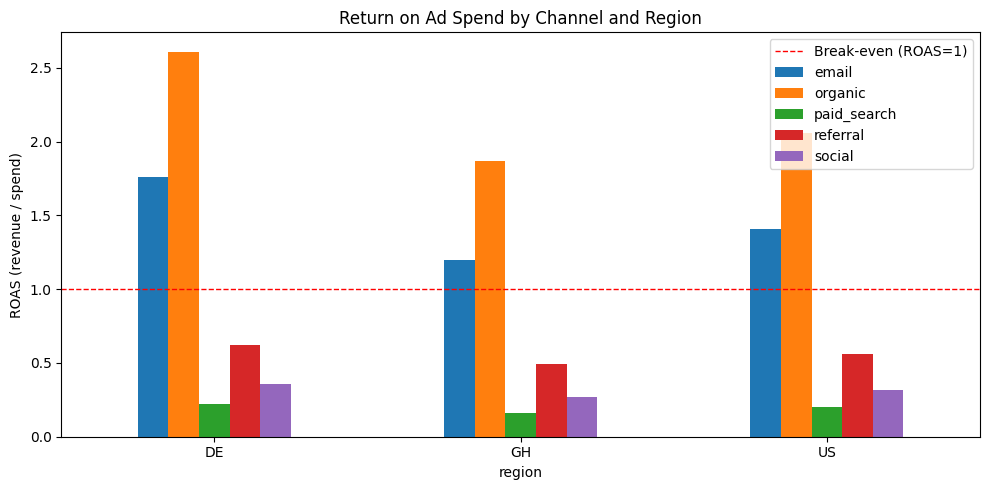

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
roas_pivot = roas['ROAS'].unstack('channel')
roas_pivot.plot(kind='bar', ax=ax)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='Break-even (ROAS=1)')
ax.set_ylabel('ROAS (revenue / spend)')
ax.set_title('Return on Ad Spend by Channel and Region')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('roas_by_channel_region.png', dpi=120)
plt.show()

## Step 4 - CAC by channel and region

Only a customer's first-ever order counts toward acquisition - identified by finding each customer's earliest order date, then looking up which channel was attributed to that specific order.

In [5]:
first_order_idx = attributed_orders.groupby('customer_id')['order_date'].idxmin()
acquisition_orders = attributed_orders.loc[first_order_idx]

new_customers = acquisition_orders.groupby(['region', 'channel'])['customer_id'].nunique().rename('new_customers')
cac = pd.concat([new_customers, spend_by_channel], axis=1)
cac['CAC'] = cac['spend_usd'] / cac['new_customers']
cac = cac.round(2).sort_values('CAC')
cac

new_customers  spend_usd      CAC
region channel                                       
GH     organic                175    8852.39    50.59
       email                   89    6580.77    73.94
DE     organic                178   18551.71   104.22
US     organic                157   21813.26   138.94
DE     email                   98   14002.97   142.89
GH     referral                65   11047.98   169.97
US     email                   91   16377.56   179.97
GH     social                 121   39583.60   327.14
DE     referral                60   23190.98   386.52
US     referral                50   27448.59   548.97
GH     paid_search            142   79694.59   561.23
DE     social                 111   84178.21   758.36
US     social                 126   97419.88   773.17
DE     paid_search            142  167596.12  1180.25
US     paid_search            163  195895.31  1201.81

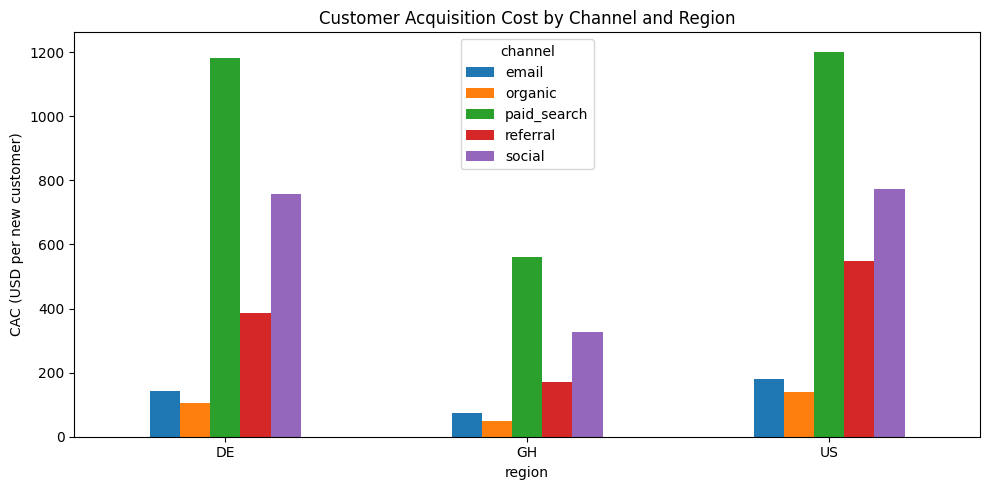

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
cac_pivot = cac['CAC'].unstack('channel')
cac_pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('CAC (USD per new customer)')
ax.set_title('Customer Acquisition Cost by Channel and Region')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cac_by_channel_region.png', dpi=120)
plt.show()

## Findings

It was found that organic and email were the only channels beating break-even (ROAS 1.2–2.6), while paid search was the weakest performer across the board — worst ROAS (0.16–0.22) and highest CAC ($565–$1,200) in every region. What stood out most was that the same channel won on both metrics in every region with no real tradeoffs, which is too clean to be realistic — a signal that the synthetic spend data needed a clear limitation note rather than being presented as a genuine finding
